# MLP feature experiment

Reads `keypoints.npz` from `extract_keypoints.ipynb`. Each image is transformed in
this order: undo ROI rotation, correct the reversed G/H/P/Q source folders for the
training corpus, mirror left hands to right, then independently min-max normalize its
42 image x/y values and 63 world-coordinate values to `[0,1]`. Image-landmark depth
(`z`, formerly “2.5d”) is deliberately excluded.

Set `FEATURES` to `"2d"`, `"3d"`, or `"2d+3d"`, run top to bottom, and the test cell
writes `runs/<mode>.npz` for `experiments.ipynb`.

train (321406, 21, 3)  val (80377, 21, 3)   26 classes

row 193748  P  deg -179.17
  kp    node  5  (+0.1321, +0.2026) -> (-0.1292, -0.2045)   dist 0.2419 -> 0.2419   angle  +56.89 -> -122.28   turned -179.17
  kp    node 12  (-0.2034, -0.2537) -> (+0.1997, +0.2566)   dist 0.3251 -> 0.3251   angle -128.72 ->  +52.10   turned -179.17
  world node  5  (+0.1713, +0.1397) -> (-0.1693, -0.1422)   dist 0.2211 -> 0.2211   angle  +39.20 -> -139.97   turned -179.17
  world node 12  (-0.5071, -0.7152) -> (+0.4967, +0.7224)   dist 0.8767 -> 0.8767   angle -125.34 ->  +55.49   turned -179.17

row 292795  X  deg -3.38
  kp    node  5  (+0.1289, -0.0477) -> (+0.1258, -0.0552)   dist 0.1374 -> 0.1374   angle  -20.31 ->  -23.69   turned -3.38
  kp    node 12  (-0.0847, -0.0281) -> (-0.0862, -0.0231)   dist 0.0892 -> 0.0892   angle -161.64 -> -165.02   turned -3.38
  world node  5  (+0.3197, +0.1094) -> (+0.3256, +0.0903)   dist 0.3379 -> 0.3379   angle  +18.89 ->  +15.51   turned -3.38
  world node 12

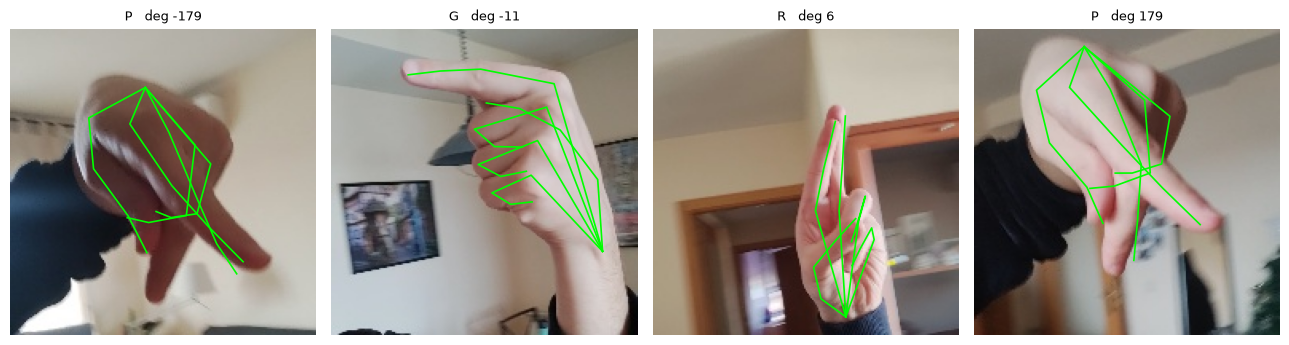

In [65]:
# --- Cached landmarks, turned back to the pose the hand was held in ----------------
# The palm detector spun every crop by deg to stand its hand up, so the cached
# landmarks lost that pose; turning them back by deg restores it in the numbers.
# kp is a fraction of the crop and turns about the crop centre; world turns about its
# origin. z is the rotation axis in both and stays unchanged. Train and val are handled
# here; the independent test capture follows the same unrotation further down.
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

KEYPOINTS = Path("keypoints.npz")   # written by extract_keypoints.ipynb
FINGERS = [(0, 1, 2, 3, 4), (0, 5, 6, 7, 8), (0, 9, 10, 11, 12),
           (0, 13, 14, 15, 16), (0, 17, 18, 19, 20)]

_z = np.load(KEYPOINTS)
CLASSES = [str(c) for c in _z["classes"]]
train_presence, train_handed, train_labels, train_deg = (
    _z["train_presence"], _z["train_handed"], _z["train_labels"], _z["train_deg"])
val_presence, val_handed, val_labels, val_deg = (
    _z["val_presence"], _z["val_handed"], _z["val_labels"], _z["val_deg"])


def unrotate(split):
    """Cached kp, world -> the same hands at the tilt they had in the source image."""
    kp, world = _z[f"{split}_kp"].copy(), _z[f"{split}_world"].copy()
    rad = np.radians(_z[f"{split}_deg"])
    c, s = np.cos(rad), np.sin(rad)
    turn = np.stack([np.stack([c, -s], -1), np.stack([s, c], -1)], -2)
    kp[..., :2] = 0.5 + np.einsum("nij,nkj->nki", turn, kp[..., :2] - 0.5)
    world[..., :2] = np.einsum("nij,nkj->nki", turn, world[..., :2])
    return kp, world


train_kp, train_world = unrotate("train")
val_kp, val_world = unrotate("val")
print(f"train {train_kp.shape}  val {val_kp.shape}   {len(CLASSES)} classes")


# --- Read the turn off the numbers -------------------------------------------------
# Polar form takes no trigonometry to check: a turn leaves every landmark the same
# distance from the centre it turns about, and advances every angle by the same deg.
# kp measures from the crop centre 0.5, world from its own origin. Printed below are
# the index knuckle and the middle fingertip on three rows spanning the range of deg.
def polar(v):
    """(x, y) offsets -> how far out each point sits, and at what angle."""
    return np.linalg.norm(v, axis=-1), np.degrees(np.arctan2(v[..., 1], v[..., 0]))


for _row in np.argsort(train_deg)[np.linspace(0, len(train_kp) - 1, 3).astype(int)]:
    print(f"\nrow {_row}  {CLASSES[train_labels[_row]]}  deg {train_deg[_row]:+.2f}")
    for _name, _was, _now in (
            ("kp   ", _z["train_kp"][_row, :, :2] - 0.5, train_kp[_row, :, :2] - 0.5),
            ("world", _z["train_world"][_row, :, :2], train_world[_row, :, :2])):
        (_r0, _a0), (_r1, _a1) = polar(_was), polar(_now)
        for _n in (5, 12):
            print(f"  {_name} node {_n:2d}  "
                  f"({_was[_n, 0]:+.4f}, {_was[_n, 1]:+.4f}) -> "
                  f"({_now[_n, 0]:+.4f}, {_now[_n, 1]:+.4f})   "
                  f"dist {_r0[_n]:.4f} -> {_r1[_n]:.4f}   "
                  f"angle {_a0[_n]:+7.2f} -> {_a1[_n]:+7.2f}   "
                  f"turned {(_a1[_n] - _a0[_n] + 180) % 360 - 180:+.2f}")

# The same two rules over every train row, not just the twelve lines printed. A point
# sitting almost on the centre is skipped, since its angle is noise at float32.
_was, _now = _z["train_kp"][..., :2] - 0.5, train_kp[..., :2] - 0.5
assert np.allclose(polar(_now)[0], polar(_was)[0], atol=1e-5)
assert np.allclose(polar(train_world[..., :2])[0],
                   polar(_z["train_world"][..., :2])[0], atol=1e-5)
_turned = polar(_now)[1] - polar(_was)[1] - train_deg[:, None]
assert np.abs((_turned + 180) % 360 - 180)[polar(_was)[0] > 0.02].max() < 0.05

# Direction is the one part the numbers cannot settle on their own, since turning the
# wrong way round obeys both rules above just as well. So put the turned landmarks back
# on the source image. roi is (cx, cy, side), so a crop-fraction offset becomes a pixel
# offset from the ROI centre once scaled by side. A skeleton lying along the hand means
# deg was undone the right way round; these four rows span its range.
_rows = np.argsort(train_deg)[np.linspace(0, len(train_kp) - 1, 4).astype(int)]
fig, axes = plt.subplots(1, 4, figsize=(13, 3.6))
for ax, row in zip(axes, _rows):
    cx, cy, side = _z["train_roi"][row]
    pts = np.array([cx, cy]) + side * (train_kp[row, :, :2] - 0.5)
    ax.imshow(cv2.cvtColor(cv2.imread(_z["train_paths"][row]), cv2.COLOR_BGR2RGB))
    for finger in FINGERS:
        ax.plot(pts[list(finger), 0], pts[list(finger), 1], "-", lw=1.2, c="lime")
    ax.set_title(f"{CLASSES[train_labels[row]]}   deg {train_deg[row]:.0f}", fontsize=9)
    ax.axis("off")
plt.tight_layout()

In [66]:
# --- Cached landmarks -> the model's input vector ----------------------------------
# Order matters: ROI rotation was undone above; reversed G/H/P/Q source folders are
# corrected for the development corpus (train and val, never the independent test),
# left hands are mirrored to right, then each image is normalized independently.
# Image-landmark z/depth is intentionally unavailable because it is not reliable.
import numpy as np

# "2d"    = per-image normalized image x,y landmarks (42)
# "3d"    = per-image normalized world x,y,z landmarks (63)
# "2d+3d" = the two independently normalized blocks (105)
FEATURES = "2d+3d"
FEATURE_DIMS = {"2d": 42, "3d": 63, "2d+3d": 105}
if FEATURES not in FEATURE_DIMS:
    raise ValueError(f"FEATURES must be one of {tuple(FEATURE_DIMS)} (got {FEATURES!r})")
IN_DIM = FEATURE_DIMS[FEATURES]

# Folders that sign these letters end for end. Turning a hand around is a half turn
# about the vertical axis, so x and z both change sign while y stays put -- that keeps
# it the same hand. A mirror, which flips x alone, would turn a right hand into a left.
FACING_LETTERS = "GHPQ"
FACING_FOLDERS = ("2", "4", "6", "9", "10", "12", "16")


def turn_around(kp, world, labels, subset):
    """Half turn about the vertical axis, for the folders that sign GHPQ backwards."""
    folder = np.array([s.split("/")[0] for s in subset])
    hit = (np.isin(labels, [CLASSES.index(c) for c in FACING_LETTERS])
           & np.isin(folder, FACING_FOLDERS))
    kp, world = kp.copy(), world.copy()
    kp[hit, :, 0] = 1.0 - kp[hit, :, 0]     # kp x is a fraction of the crop, so it
    kp[hit, :, 2] *= -1.0                   # turns about 0.5; its z is 0 at the wrist
    world[hit, :, 0] *= -1.0
    world[hit, :, 2] *= -1.0
    return kp, world, hit


def mirror(kp, world, handed):
    """Left hands folded onto right, so one sign is one shape. Only x moves."""
    flip = handed < 0.5
    kp, world = kp.copy(), world.copy()
    kp[flip, :, 0] = 1.0 - kp[flip, :, 0]
    world[flip, :, 0] *= -1.0
    return kp, world


train_y, val_y = train_labels, val_labels
tr_kp, tr_w, tr_hit = turn_around(train_kp, train_world, train_y, _z["train_subset"])
va_kp, va_w, va_hit = turn_around(val_kp, val_world, val_y, _z["val_subset"])
tr_kp, tr_w = mirror(tr_kp, tr_w, train_handed)
va_kp, va_w = mirror(va_kp, va_w, val_handed)
tr_w -= tr_w[:, :1, :]
va_w -= va_w[:, :1, :]


def minmax_per_sample(values):
    """Flatten each image and independently map its finite values to [0,1]."""
    flat = np.asarray(values, dtype=np.float32).reshape(len(values), -1)
    low = flat.min(axis=1, keepdims=True)
    width = flat.max(axis=1, keepdims=True) - low
    # A constant or invalid row has no scale; 0.5 is the neutral fallback used for an
    # unreadable test frame rather than dividing by zero or propagating NaN.
    return np.divide(flat - low, width, out=np.full_like(flat, 0.5),
                     where=np.isfinite(width) & (width > 0))


def features(kp, world):
    """Build per-image normalized 2D, 3D, or independently normalized 2D+3D vectors."""
    xy = minmax_per_sample(kp[..., :2])       # 42 x/y values; landmark depth is discarded
    world3d = minmax_per_sample(world)         # 63 world x/y/z values
    return {"2d": xy, "3d": world3d,
            "2d+3d": np.concatenate([xy, world3d], axis=1)}[FEATURES]


def assert_per_sample_normalized(X):
    """Every selected block spans [0,1], or is the neutral constant 0.5 block."""
    blocks = {"2d": (X,), "3d": (X,), "2d+3d": (X[:, :42], X[:, 42:])}[FEATURES]
    assert X.shape[1] == IN_DIM and np.isfinite(X).all()
    for block in blocks:
        neutral = np.all(block == 0.5, axis=1)
        scaled = (np.isclose(block.min(axis=1), 0.0)
                  & np.isclose(block.max(axis=1), 1.0))
        assert np.all(neutral | scaled)


# Small executable check for normal and zero-range rows.
_probe = minmax_per_sample(np.array([[2.0, 4.0, 6.0], [9.0, 9.0, 9.0]], np.float32))
assert np.allclose(_probe[0], (0.0, 0.5, 1.0)) and np.all(_probe[1] == 0.5)

X_train, X_val = features(tr_kp, tr_w), features(va_kp, va_w)
assert X_train.shape == (len(train_y), IN_DIM) and X_val.shape == (len(val_y), IN_DIM)
assert_per_sample_normalized(X_train)
assert_per_sample_normalized(X_val)

# Turning is not flipping, and the difference only shows in 3d: a half turn is det +1
# and leaves the hand the same hand, a mirror is det -1 and swaps it for the other one.
# The signed volume at the wrist is that chirality, so it has to survive the turn and
# reverse for exactly the left hands the fold mirrored, and for nothing else.
def _chirality(a):
    u, v, t = a[:, 5] - a[:, 0], a[:, 17] - a[:, 0], a[:, 9] - a[:, 0]
    return np.sign(np.einsum("ni,ni->n", np.cross(u, v), t))


assert np.array_equal(_chirality(tr_w),
                      np.where(train_handed < 0.5, -1, 1) * _chirality(train_world))
# H is the letter whose folders split most cleanly, so once the turned ones are turned
# they must wind the same way round as the ones that were left alone.
_p = tr_kp[:, [0, 5, 9, 13, 17], :2]
_wind = np.sign(sum(_p[:, i, 0] * _p[:, (i + 1) % 5, 1]
                    - _p[:, (i + 1) % 5, 0] * _p[:, i, 1] for i in range(5)))
_h = train_y == CLASSES.index("H")
assert _wind[_h & tr_hit].mean() * _wind[_h & ~tr_hit].mean() > 0, "facing fix inverted"

print(f"FEATURES {FEATURES!r} -> {IN_DIM} dims; image depth discarded")
print(f"turned around {tr_hit.sum():,} train and {va_hit.sum():,} val rows "
      f"({', '.join(FACING_LETTERS)} in folders {', '.join(FACING_FOLDERS)}; never test)")
print(f"mirrored {np.mean(train_handed < 0.5):.1%} of train (the left hands)")
print(f"X_train {X_train.shape}  X_val {X_val.shape}; "
      "each selected block normalized independently per image to [0,1]")

FEATURES '2d+3d' -> 105 dims; image depth discarded
turned around 12,355 train and 3,096 val rows (G, H, P, Q in folders 2, 4, 6, 9, 10, 12, 16; never test)
mirrored 24.6% of train (the left hands)
X_train (321406, 105)  X_val (80377, 105); each selected block normalized independently per image to [0,1]


In [67]:
# --- Test capture -> the same input vector, minus the facing correction ------------
# The independent test capture signs G/H/P/Q correctly, so it is not turned around.
# It is still unrotated, mirrored left-to-right, and normalized independently per image
# with the same feature function as train and validation.
test_labels, test_presence, test_handed, test_left, test_palm = (
    _z["test_labels"], _z["test_presence"], _z["test_handed"], _z["test_left"],
    _z["test_palm"])
test_y = test_labels
# The cache gates nothing, so the palm score and the hand-presence score arrive raw
# and the evaluation picks its own thresholds; jazz's own are 0.5 and 0.5. NaN means
# the image would not decode, the one case with no numbers behind it at all.
test_scored = np.isfinite(test_presence)

# Which hand it is can come from the folder, which is the honest answer, or from the
# landmark net, which is the only answer the app will ever have. The net's is used, so
# that a row is folded here exactly as its like was folded in training, and so that a
# handedness mistake costs a mark at test time just as it would on a phone.
te_kp, te_w = unrotate("test")
te_kp, te_w = mirror(te_kp, te_w, test_handed)
te_w -= te_w[:, :1, :]
# Every valid frame gets its own 2D/3D min and max. The one undecodable frame has no
# finite scale and remains the neutral all-0.5 vector.
X_test = np.where(test_scored[:, None], features(te_kp, te_w), 0.5).astype(np.float32)

assert X_test.shape == (len(test_y), IN_DIM)
assert_per_sample_normalized(X_test)
# Folder and net are two independent readings of the same thing, so agreement says the
# folders are named the way round they look; swapped folders would score near zero.
# Only the rows jazz would believe are asked, since a palm found at 0.02 confidence
# has no opinion on handedness worth counting.
_jazz = (test_palm >= 0.5) & (test_presence >= 0.5)
_same = (test_left == (test_handed < 0.5))[_jazz]
assert _same.mean() > 0.9, "left/ and right/ look swapped"

print(f"X_test {X_test.shape}   at jazz's 0.5 and 0.5, "
      f"{np.mean(test_palm >= 0.5):.1%} of frames clear the palm and "
      f"{_jazz.mean():.1%} clear both")
print(f"folder and landmark net agree on which hand for {_same.mean():.1%} of those; "
      f"{np.mean((test_handed < 0.5)[_jazz]):.1%} were folded onto right")
print(f"{np.bincount(test_y).min()} frames for every letter; of the worst-served one "
      f"jazz would refuse {np.bincount(test_y[~_jazz]).max()}")

X_test (3744, 105)   at jazz's 0.5 and 0.5, 92.9% of frames clear the palm and 87.3% clear both
folder and landmark net agree on which hand for 94.3% of those; 45.3% were folded onto right
144 frames for every letter; of the worst-served one jazz would refuse 63


In [68]:
X_train[0]

array([0.560632  , 0.92305225, 0.84932446, 0.6993519 , 1.        ,
       0.43835142, 0.9359869 , 0.22615653, 0.8156628 , 0.06936646,
       0.68155116, 0.2551993 , 0.60822636, 0.09716491, 0.7078075 ,
       0.3411589 , 0.7221087 , 0.38983032, 0.4419099 , 0.33356524,
       0.40634796, 0.18991965, 0.53997093, 0.4685817 , 0.5331497 ,
       0.48300424, 0.23104496, 0.4197232 , 0.18164611, 0.2517955 ,
       0.33308595, 0.50417835, 0.33092743, 0.52079403, 0.02692213,
       0.5227163 , 0.        , 0.36928773, 0.14874691, 0.5401121 ,
       0.18317604, 0.57841283, 0.7113949 , 0.7113949 , 0.7113949 ,
       0.90964794, 0.48975667, 0.6508167 , 0.9962416 , 0.2904797 ,
       0.65276474, 1.        , 0.1196777 , 0.6025687 , 0.87778276,
       0.        , 0.5901822 , 0.7811619 , 0.10020305, 0.730971  ,
       0.7522801 , 0.01873992, 0.58121836, 0.7704086 , 0.11175736,
       0.5707607 , 0.7995723 , 0.22657314, 0.6719008 , 0.5842943 ,
       0.15519181, 0.71882886, 0.5509851 , 0.02256568, 0.49979

In [69]:
# --- Classifier: flattened landmarks -> letter ------------------------------------
# One block per hidden layer: Linear, BatchNorm, ReLU, Dropout -- normalising before
# the nonlinearity keeps activations centred where ReLU is informative.
# The head stays a bare Linear because CrossEntropyLoss wants raw logits; normalising
# or dropping them would fight the loss rather than regularise it.
import torch
import torch.nn as nn

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
HIDDEN = (512,256,128)
DROPOUT = 0.1
LR = 2e-5
BATCH_NORM = True


def build_mlp(in_dim=IN_DIM, hidden=HIDDEN, n_classes=len(CLASSES),
              dropout=DROPOUT, batch_norm=BATCH_NORM):
    layers, prev = [], in_dim
    for width in hidden:
        layers.append(nn.Linear(prev, width))
        if batch_norm:
            layers.append(nn.BatchNorm1d(width))
        layers += [nn.ReLU(), nn.Dropout(dropout)]
        prev = width
    return nn.Sequential(*layers, nn.Linear(prev, n_classes))


model = build_mlp().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print(model)
print(f"{sum(t.numel() for t in model.parameters()):,} parameters on {DEVICE}  "
      f"({FEATURES!r}, {IN_DIM} dims)")

Sequential(
  (0): Linear(in_features=105, out_features=512, bias=True)
  (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.1, inplace=False)
  (4): Linear(in_features=512, out_features=256, bias=True)
  (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (6): ReLU()
  (7): Dropout(p=0.1, inplace=False)
  (8): Linear(in_features=256, out_features=128, bias=True)
  (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (10): ReLU()
  (11): Dropout(p=0.1, inplace=False)
  (12): Linear(in_features=128, out_features=26, bias=True)
)
223,642 parameters on cuda  ('2d+3d', 105 dims)


train:   0%|          | 0/50 [00:00<?, ?ep/s]

train:   2%|▏         | 1/50 [00:07<05:53,  7.21s/ep]

  1  train 1.0783 / 84.56%   val 0.3339 / 96.16%   lr 2.00e-05


train:  10%|█         | 5/50 [00:36<05:31,  7.36s/ep]

  5  train 0.0717 / 98.27%   val 0.0448 / 98.79%   lr 2.00e-05


...

 40  train 0.0145 / 99.57%   val 0.0124 / 99.68%   lr 2.00e-05


train:  90%|█████████ | 45/50 [05:52<00:40,  8.18s/ep]

 45  train 0.0134 / 99.61%   val 0.0121 / 99.69%   lr 2.00e-05


train: 100%|██████████| 50/50 [06:28<00:00,  7.77s/ep]

 50  train 0.0123 / 99.63%   val 0.0109 / 99.72%   lr 2.00e-05

final val accuracy 99.72%, final weights saved to weights/2d+3d_mlp.pt


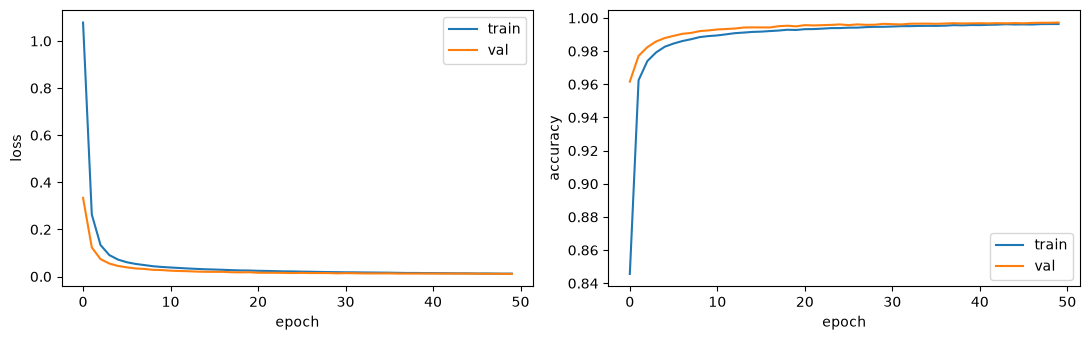

In [70]:
# --- Training ---------------------------------------------------------------------
# The whole split sits on DEVICE; each batch is just an index slice, so there is no
# per-batch host transfer. This uses the winning tuning hyperparameters: fixed Adam
# learning rate, all 250 epochs, no scheduler, no weight decay and no early stopping.
#
# Rerunning this cell continues training the model as it stands. Rerun the classifier
# cell first for a fresh start, otherwise the optimiser state and weights carry over.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm.auto import tqdm

BATCH_SIZE = 128
EPOCHS = 50
WEIGHTS = Path("weights")
WEIGHTS.mkdir(exist_ok=True)
MLP_CKPT = WEIGHTS / f"{FEATURES}_mlp.pt"

assert len(X_train) == len(train_y) and len(X_val) == len(val_y), "rerun the cells above"
assert model[0].in_features == X_train.shape[1], "model predates the current vectors"

X_tr = torch.from_numpy(X_train).to(DEVICE)
y_tr = torch.from_numpy(train_y).to(DEVICE)
X_va = torch.from_numpy(X_val).to(DEVICE)
y_va = torch.from_numpy(val_y).to(DEVICE)


def run_epoch(X, y, train):
    """One pass over rows already on DEVICE -> mean loss, accuracy."""
    model.train(train)
    n = len(y)
    order = torch.randperm(n, device=DEVICE) if train else torch.arange(n, device=DEVICE)
    if train:                                   # BatchNorm needs more than one row
        order = order[: (n // BATCH_SIZE) * BATCH_SIZE]
    loss_sum = correct = seen = 0.0
    with torch.set_grad_enabled(train):
        for start in range(0, len(order), BATCH_SIZE):
            idx = order[start:start + BATCH_SIZE]
            logits = model(X[idx])
            loss = criterion(logits, y[idx])
            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
            bs = len(idx)
            loss_sum += loss.detach() * bs
            correct += (logits.argmax(1) == y[idx]).sum()
            seen += bs
    return (loss_sum / seen).item(), (correct / seen).item()


history = []
for epoch in tqdm(range(1, EPOCHS + 1), desc="train", unit="ep"):
    tr_loss, tr_acc = run_epoch(X_tr, y_tr, True)
    va_loss, va_acc = run_epoch(X_va, y_va, False)
    history.append((tr_loss, tr_acc, va_loss, va_acc))
    if epoch == 1 or epoch % 5 == 0:
        print(f"{epoch:3d}  train {tr_loss:.4f} / {tr_acc:6.2%}   "
              f"val {va_loss:.4f} / {va_acc:6.2%}   lr {LR:.2e}")

best_acc = history[-1][3]  # compatibility name: tuning scores the final epoch
torch.save(model.state_dict(), MLP_CKPT)
print(f"\nfinal val accuracy {best_acc:.2%}, final weights saved to {MLP_CKPT}")

hist = np.array(history)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, col, name in zip(axes, (0, 1), ("loss", "accuracy")):
    ax.plot(hist[:, col], label="train")
    ax.plot(hist[:, col + 2], label="val")
    ax.set_xlabel("epoch")
    ax.set_ylabel(name)
    ax.legend()
plt.tight_layout()

3,744 frames, 144 of every letter, left and right
  palm found        3,480    92.95% of all
  hand confirmed    3,267    87.26% of all
  letter correct    2,786    74.41% of all
                    2,786    85.28% of the confirmed
  the hand filmed  left 68.59%   right 80.24%

per letter, out of 144 frames each, worst first
  N   palm  86%   hand  56%   correct  37%   of confirmed  65%  ###########
  D   palm  73%   hand  73%   correct  56%   of confirmed  77%  #################
  T   palm  90%   hand  72%   correct  59%   of confirmed  83%  ##################
  R   palm  92%   hand  88%   correct  59%   of confirmed  67%  ##################
  Z   palm  80%   hand  72%   correct  60%   of confirmed  83%  ##################
  A   palm 100%   hand  89%   correct  61%   of confirmed  69%  ##################
  M   palm  94%   hand  88%   correct  62%   of confirmed  70%  ###################
  J   palm  74%   hand  71%   correct  63%   of confirmed  89%  ###################
  F   palm  67%

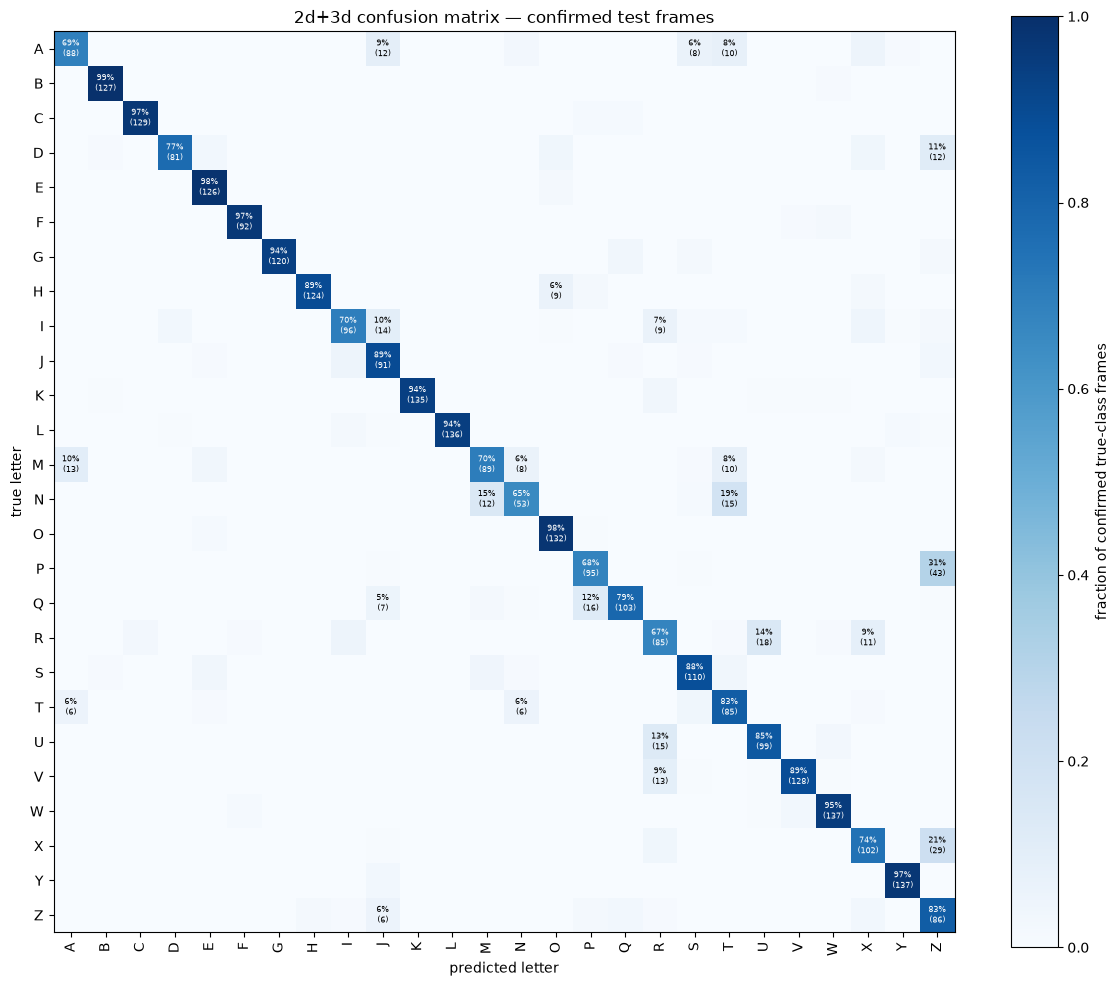

In [71]:
# --- Test: three numbers, one denominator -----------------------------------------
# jazz rejects with `confidence < threshold`, at MediaPipePalmDetector.cs:328 and at
# HandPoseDetectionEngine.cs:255, so a score sitting exactly on the threshold is kept
# and >= is the comparison that matches it. The gates are a chain: presence is only
# ever asked about a frame a palm was found in. Both are quoted out of every frame
# filmed, never out of the survivors of the step before, because a denominator that
# shrinks at each step is what lets a pipeline look accurate by answering less.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

RUNS_DIR = Path("runs")     # one <FEATURES>.npz per mode, read by experiments.ipynb
PALM_MIN = 0.5              # jazz HandPoseDetector.prefab palmConfidenceThreshold
PRESENCE_MIN = 0.5          # jazz HandPoseDetector.prefab handPoseConfidenceThreshold

found = test_palm >= PALM_MIN
sure = found & (test_presence >= PRESENCE_MIN)

model.eval()
with torch.no_grad():
    pred = model(torch.from_numpy(X_test).to(DEVICE)).argmax(1).cpu().numpy()
# A frame no hand was ever found in cannot be answered correctly, whatever the model
# happens to reply to the filler row standing in for it.
hit = sure & (pred == test_y)

n, each = len(test_y), np.bincount(test_y).min()
assert hit.sum() <= sure.sum() <= found.sum() <= n, "a stage passed on more than it got"

print(f"{n:,} frames, {each} of every letter, left and right")
print(f"  palm found       {found.sum():6,}   {found.mean():7.2%} of all")
print(f"  hand confirmed   {sure.sum():6,}   {sure.mean():7.2%} of all")
print(f"  letter correct   {hit.sum():6,}   {hit.mean():7.2%} of all")
# Same numerator, smaller denominator: the model marked only on the frames it was
# actually handed landmarks for, which is the classifier on its own with the
# detector's misses set aside. The line above is what a user would feel.
print(f"                   {hit.sum():6,}   {hit.sum() / sure.sum():7.2%} of the confirmed")
print(f"  the hand filmed  left {hit[test_left].mean():.2%}   "
      f"right {hit[~test_left].mean():.2%}")

print(f"\nper letter, out of {each} frames each, worst first")
for h, f, s, name in sorted((hit[test_y == i].mean(), found[test_y == i].mean(),
                             sure[test_y == i].mean(), CLASSES[i])
                            for i in range(len(CLASSES))):
    print(f"  {name}   palm {f:4.0%}   hand {s:4.0%}   correct {h:4.0%}"
          f"   of confirmed {h / s if s else np.nan:4.0%}  " + "#" * round(h * 30))

# Classifier confusion only: rejected frames never reached a trustworthy landmark row,
# so they remain in the coverage numbers above rather than becoming a fake 27th class.
confusion = np.zeros((len(CLASSES), len(CLASSES)), dtype=int)
np.add.at(confusion, (test_y[sure], pred[sure]), 1)
row_total = confusion.sum(axis=1, keepdims=True)
confusion_rate = np.divide(confusion, row_total, out=np.zeros_like(confusion, dtype=float),
                           where=row_total > 0)
fig, ax = plt.subplots(figsize=(12, 10))
image = ax.imshow(confusion_rate, cmap="Blues", vmin=0, vmax=1)
ax.set(title=f"{FEATURES} confusion matrix — confirmed test frames",
       xlabel="predicted letter", ylabel="true letter")
ax.set_xticks(np.arange(len(CLASSES)))
ax.set_yticks(np.arange(len(CLASSES)))
ax.set_xticklabels(CLASSES, rotation=90)
ax.set_yticklabels(CLASSES)
for true, predicted in zip(*np.where((confusion_rate >= 0.05) & (confusion > 0))):
    rate = confusion_rate[true, predicted]
    ax.text(predicted, true, f"{rate:.0%}\n({confusion[true, predicted]})",
            ha="center", va="center", fontsize=6,
            color="white" if rate > 0.5 else "black")
fig.colorbar(image, ax=ax).set_label("fraction of confirmed true-class frames")
plt.tight_layout()

# Everything experiments.ipynb needs to draw this run, one file per feature mode. A
# frame that never cleared the gates is saved as "-", not as whatever the model said,
# so the file cannot be re-scored into a flattering number later.
RUNS_DIR.mkdir(exist_ok=True)
np.savez(RUNS_DIR / f"{FEATURES}.npz",
         features=FEATURES, dims=IN_DIM, normalization="per-sample-minmax",
         image_depth=False, hidden=np.array(HIDDEN), dropout=DROPOUT,
         lr=LR, batch_norm=BATCH_NORM, batch_size=BATCH_SIZE, epochs=EPOCHS,
         optimizer="Adam", weight_decay=0.0, scheduler=False, early_stopping=False,
         history=hist, best_val=best_acc, validation_metric="final_epoch",
         y_true=np.array(CLASSES)[test_y],
         y_pred=np.where(sure, np.array(CLASSES)[pred], "-"),
         palm=test_palm, presence=test_presence, left=test_left)
print(f"\nsaved -> {RUNS_DIR / f'{FEATURES}.npz'}")